In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.7.1+cu118
0.22.1+cu118


In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
def set_seeds(seed:int=42):
    """sets random seed for torch operation
    Args:
        seed(int,optional):random seed to set. Deafualt to 42.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [4]:
set_seeds()


In [5]:
#fuction for downloading the data
import os 
import zipfile
from pathlib import Path
import requests

def download_data(source:str,
                  destination:str,
                  remove_sourse:bool=True)->Path:
    """downloads a zipped datasets from source and unzips to destination."""

    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"{image_path} directory exists,skipping redownloading....")
    else:
        print(f"Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
    
        # Download pizza, steak, sushi data
        target_file=Path(source).name
        with open(data_path /target_file, "wb") as f:
            request = requests.get(source)
            print("Downloading target file from source")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"Unzipping{target_file} data...") 
            zip_ref.extractall(image_path)
    
        # Remove zip file
        os.remove(data_path /target_file)
    return image_path

In [6]:
image_path=download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                         destination="pizza_steak_sushi")

image_path

data\pizza_steak_sushi directory exists,skipping redownloading....


WindowsPath('data/pizza_steak_sushi')

In [7]:
train_dir=image_path/"train"
test_dir=image_path/"test"

In [8]:
#setup imagenet normalization levels
from torchvision import transforms
normalize=transforms.Normalize(mean=[0.485,0.456,0.406],
                               std=[0.229,0.224,0.225])
#transform pipline manually

manual_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

print(f"manually created transforms:{manual_transforms}")

from going_modular import data_setup
train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=32
)
train_dataloader,test_dataloader,class_names

manually created transforms:Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x1dd99efc890>,
 ['pizza', 'steak', 'sushi'])

In [9]:
#transform pipeline automatically
import torchvision
weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
automatic_transforms=weights.transforms()
print(f"automatically created transforms: {automatic_transforms}")

train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=automatic_transforms,
    batch_size=32
)
train_dataloader,test_dataloader,class_names

automatically created transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x1dde5db5e20>,
 ['pizza', 'steak', 'sushi'])

In [10]:
# model=torchvision.models.efficientnet_b0(pretrained=True).to(device)
# model

#or

weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT

model=torchvision.models.efficientnet_b0(weights=weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
#to freeze all base layer(feature extraction)
for param in model.features.parameters():
    # print(param)
    param.requires_grad=False

In [12]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [13]:
#adjust classifier output
from torch import nn
set_seeds()
model.classifier=nn.Sequential(
    nn.Dropout(p=0.2,inplace=True),
    nn.Linear(in_features=1280,out_features=len(class_names)).to(device)
)

In [14]:
from torchinfo import summary

summary(model,
        input_size=(32,3,224,224),
        verbose=0,
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [15]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [16]:
#setup a summarywriter

from torch.utils.tensorboard import SummaryWriter
writer=SummaryWriter()
writer

In [17]:
from going_modular.engine import train_step,test_step
from typing import Dict,List,Tuple
from tqdm.auto import tqdm

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List[float]]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]} 
    For example if training for epochs=2: 
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]} 
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
      test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)

      ##new:experiment trackin
      writer.add_scalars(main_tag="Loss",
                        tag_scalar_dict={"train_loss": train_loss,
                                         "test_loss":test_loss},
                        global_step=epoch)
      writer.add_scalars(main_tag="Accuracy",
                        tag_scalar_dict={"train_acc":train_acc,
                                         "test_acc":test_acc},
                        global_step=epoch)
      writer.add_graph(model=model,
                       input_to_model=torch.rand(32,3,224,224).to(device))

  writer.close()
  # Return the filled results at the end of the epochs
  return results


C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
set_seeds()
results=train(model=model,
              train_dataloader=train_dataloader,
              test_dataloader=test_dataloader,
              optimizer=optimizer,
              loss_fn=loss_fn,
              epochs=5,
              device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0947 | train_acc: 0.4023 | test_loss: 0.9138 | test_acc: 0.5502


 20%|██        | 1/5 [00:09<00:37,  9.29s/it]

Epoch: 2 | train_loss: 0.8952 | train_acc: 0.6562 | test_loss: 0.7852 | test_acc: 0.8258


 40%|████      | 2/5 [00:18<00:28,  9.43s/it]

...

 60%|██████    | 3/5 [00:24<00:15,  7.51s/it]

Epoch: 4 | train_loss: 0.6844 | train_acc: 0.8516 | test_loss: 0.6712 | test_acc: 0.8561


 80%|████████  | 4/5 [00:27<00:05,  5.82s/it]

Epoch: 5 | train_loss: 0.7056 | train_acc: 0.7227 | test_loss: 0.6758 | test_acc: 0.7633


100%|██████████| 5/5 [00:30<00:00,  6.13s/it]


In [19]:
%load_ext tensorboard
%tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 12788), started 7 days, 20:36:38 ago. (Use '!kill 12788' to kill it.)

In [20]:
#create a function to prepare a summarywriter() instance
from torch.utils.tensorboard import SummaryWriter
def create_writer(experiment_name:str,
                  model_name:str,
                  extra:str=None):
    """creates a torch.utils.tensorboard.writer.summarywriter() instance tracking  to a spcefic directory"""
    from datetime import datetime
    import os
    timestamp=datetime.now().strftime("%Y-%m-%d")
    if extra:
        log_dir=os.path.join("runs",timestamp,experiment_name,model_name,extra)
    else:
        log_dir=os.path.join("runs",timestamp,experiment_name,model_name)
    print(f"[INFO] created summaarywriter saveing to {log_dir}")
    return SummaryWriter(log_dir=log_dir)
    

In [21]:
example_writer=create_writer(experiment_name="data_10__percent",
                             model_name="effnetb0",
                             extra="5_epochs")
example_writer

[INFO] created summaarywriter saveing to runs\2025-07-07\data_10__percent\effnetb0\5_epochs


In [22]:
import torch.utils.tensorboard
from going_modular.engine import train_step,test_step
from typing import Dict,List,Tuple
from tqdm.auto import tqdm

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          writer:torch.utils.tensorboard.SummaryWriter) -> Dict[str, List[float]]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]} 
    For example if training for epochs=2: 
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]} 
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
      test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)



      ##new:experiment trackin
      if writer:
        writer.add_scalars(main_tag="Loss",
                            tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss":test_loss},
                            global_step=epoch)
        writer.add_scalars(main_tag="Accuracy",
                            tag_scalar_dict={"train_acc":train_acc,
                                            "test_acc":test_acc},
                            global_step=epoch)
        writer.add_graph(model=model,
                        input_to_model=torch.rand(32,3,224,224).to(device))

        writer.close()
      else:
         pass
  # Return the filled results at the end of the epochs
  return results


In [23]:
#now we will experiment and run 2 different model with different hyper parameters with differennt datasets and many more

#downloading different datasets

# Download 10 percent and 20 percent datasets
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")


data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data\pizza_steak_sushi directory exists,skipping redownloading....
data\pizza_steak_sushi_20_percent directory exists,skipping redownloading....


In [24]:
train_dir_10=data_10_percent_path/"train"
train_dir_20=data_20_percent_path/"train"

test_dir=data_10_percent_path/"test"

train_dir_10,train_dir_20,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [25]:
normalize=transforms.Normalize(mean=[0.485,0.456,0.406],
                               std=[0.229,0.224,0.225])

simple_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [26]:
BATCH_SIZE=32

train_dataloader_10,test_dataloader,class_names=data_setup.create_dataloaders(train_dir=train_dir_10,
                                                                              test_dir=test_dir,
                                                                              transform=simple_transform,
                                                                              batch_size=BATCH_SIZE
                                                                              )

train_dataloader_20,test_dataloader,class_names=data_setup.create_dataloaders(train_dir=train_dir_20,
                                                                              test_dir=test_dir,
                                                                              transform=simple_transform,
                                                                              batch_size=BATCH_SIZE
                                                                              )
len(train_dataloader_10),len(train_dataloader_20),len(test_dataloader),class_names

(8, 15, 3, ['pizza', 'steak', 'sushi'])

In [27]:
import torchvision

effnetb2_weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2=torchvision.models.efficientnet_b2(weights=effnetb2_weights)
effnetb2

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
from torchinfo import summary

summary(model=effnetb2,
        input_size=(32,3,224,224),
        verbose=0,
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [29]:
import torchvision
from torch import nn

OUT_FEATURES=len(class_names)

def create_effnetb0():
    weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model=torchvision.models.efficientnet_b0(weights=weights).to(device)

    #freeze the base model layers
    for param in model.features.parameters():
        param.requires_grad=False

    set_seeds()
    model.classifier=nn.Sequential(
        nn.Dropout(p=0.2,inplace=True),
        nn.Linear(in_features=1280,out_features=OUT_FEATURES)
    ).to(device)

    model.name="effnetb0"
    print(f"[INFO] created new {model.name} model.....")
    return model

def create_effnetb2():
    weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model=torchvision.models.efficientnet_b2(weights=weights).to(device)

    #freeze the base model layers
    for param in model.features.parameters():
        param.requires_grad=False

    set_seeds()
    model.classifier=nn.Sequential(
        nn.Dropout(p=0.3,inplace=True),
        nn.Linear(in_features=1408,out_features=OUT_FEATURES)
    ).to(device)

    model.name="effnetb0"
    print(f"[INFO] created new {model.name} model.....")
    return model

In [30]:
create_model_test_1=create_effnetb0()
create_model_test_2=create_effnetb2()

[INFO] created new effnetb0 model.....
[INFO] created new effnetb0 model.....


In [31]:
from torchinfo import summary

summary(model=create_model_test_2,
        input_size=(32,3,224,224),
        verbose=0,
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [32]:
from torchinfo import summary

summary(model=create_model_test_1,
        input_size=(32,3,224,224),
        verbose=0,
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [33]:
num_epochs=[5,10]
models=["effnetb0","effnetb2"]

train_dataloaders={"data_10_percent":train_dataloader_10,
                  "data_20_percent":train_dataloader_20}


In [34]:
%%time

from going_modular.utils import save_model

set_seeds(seed=42)

experiment_number=0

for dataloader_name,train_dataloader in train_dataloaders.items():
    for epochs in num_epochs:
        for model_name in models:

            experiment_number+=1
            print(f"[INFO] experiment number: {experiment_number}")
            print(f"[INFO] model: {model_name}")
            print(f"[INFO] dataloader: {dataloader_name}")
            print(f"[INFO] number of epochs: {epochs}")

            if model_name == "effnetb0":
                model=create_effnetb0()
            else:
                model=create_effnetb2()
            loss_fn=nn.CrossEntropyLoss()
            optimizer=torch.optim.Adam(params=model.parameters(),lr=0.001)
            train(model=model,
                  train_dataloader=train_dataloader,
                  test_dataloader=test_dataloader,
                  optimizer=optimizer,
                  loss_fn=loss_fn,
                  epochs=epochs,
                  device=device,
                  writer=create_writer(experiment_name=dataloader_name,
                                       model_name=model_name,
                                       extra=f"{epochs}_epochs"))
            save_filepath=f"08_{model_name}_{dataloader_name}_{epochs}_epochs.pth"
            save_model(model=model,
                       target_dir="models",
                       model_name=save_filepath)
            print("-"*50+"\n")

[INFO] experiment number: 1
[INFO] model: effnetb0
[INFO] dataloader: data_10_percent
[INFO] number of epochs: 5
[INFO] created new effnetb0 model.....
[INFO] created summaarywriter saveing to runs\2025-07-07\data_10_percent\effnetb0\5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0419 | train_acc: 0.5078 | test_loss: 0.9291 | test_acc: 0.4678


 20%|██        | 1/5 [00:02<00:11,  2.98s/it]

Epoch: 2 | train_loss: 0.9355 | train_acc: 0.5391 | test_loss: 0.8389 | test_acc: 0.5492


...

Epoch: 9 | train_loss: 0.3488 | train_acc: 0.8938 | test_loss: 0.4370 | test_acc: 0.8674


 90%|█████████ | 9/10 [00:50<00:05,  5.64s/it]

Epoch: 10 | train_loss: 0.3729 | train_acc: 0.8667 | test_loss: 0.3764 | test_acc: 0.9489


100%|██████████| 10/10 [00:56<00:00,  5.62s/it]

[INFO] Saving model to: models\08_effnetb2_data_20_percent_10_epochs.pth
--------------------------------------------------

CPU times: total: 39.6 s
Wall time: 4min 13s


In [35]:
#visualize


In [36]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 12788), started 7 days, 20:40:53 ago. (Use '!kill 12788' to kill it.)

The best performing model was:
* model:effnetb2
* dataset: 20%
* epochs:10


overall trend of all the results was that more data, bigger model and longer training time generally lead to better results

In [38]:
#loading the best model
best_model_path="models/08_effnetb2_data_20_percent_10_epochs.pth"

best_model=create_effnetb2()

best_model.load_state_dict(torch.load(best_model_path))

[INFO] created new effnetb0 model.....


<All keys matched successfully>

In [55]:
#cheking the model file size

from pathlib import Path

effnetb2_model_size=Path(best_model_path).stat().st_size//(1024*1024)
print(f"efficientnetb2 feature extraxtor model size: {effnetb2_model_size}MB")

efficientnetb2 feature extraxtor model size: 29MB


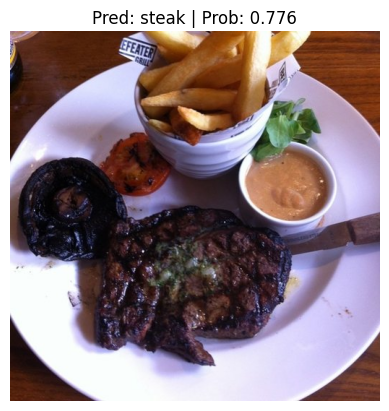

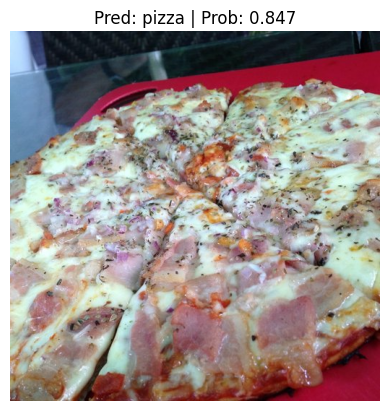

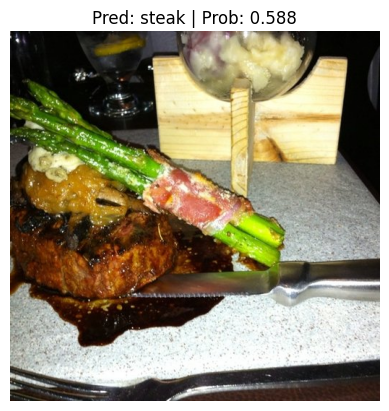

In [81]:

from going_modular.predictions import pred_and_plot_image

#3 random image path names

import random
num_images_to_plot=3
test_image_path_list=list(Path(data_20_percent_path/"test").glob("*/*.jpg"))
test_image_path_sample=random.sample(test_image_path_list,
                                     k=num_images_to_plot)
for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_model,
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224,224))